# Radiation Comparison between Models 

Short wave solar radiation is biologically important. Would be a great idea to compare it in different models, especially `HRDPS` and `CaSR`.



## Construct year-averaged files



### CaSR

CaSR file names:

    Integrated_RDPS_P_FB_SFC_2008_2024.nc   Integrated_RDPS_P_PR0_SFC_2008_2024.nc
    Integrated_RDPS_P_FI_SFC_2008_2024.nc   Integrated_RDPS_P_TT_1.5m_2008_2024.nc
    Integrated_RDPS_P_HU_1.5m_2008_2024.nc  Integrated_RDPS_P_UUC_10m_2008_2024.nc
    Integrated_RDPS_P_PN_SFC_2008_2024.nc   Integrated_RDPS_P_VVC_10m_2008_2024.nc

Base path: `/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/`

In [1]:
import xarray as xr

path_casr='/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_FB_SFC_2008_2024.nc'

ds_casr=xr.open_dataset(path_casr)

In [5]:
import sys

sys.path.append("/home/jqiu/analysis-junqi/Tools-Junqi")

import junqi_nctool as jqnc

jqnc.nc_disp(path_casr,detailed=True)

### NetCDF Summary

*Path: : `/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_FB_SFC_2008_2024.nc`*

#### Dimensions

Dimension,Size
time,149040
rlat,105
rlon,70


#### Variables

Name,Shape,Dimensions,Long Name,Units
rotated_pole,(),scalar,,
CaSR_v3.2_P_FB_SFC,"(149040, 105, 70)","time, rlat, rlon",Forecast: Downward solar flux at surface,W m**-2
time,"(149040,)",time,Validity time,
lon,"(105, 70)","rlat, rlon",longitude,degrees_east
lat,"(105, 70)","rlat, rlon",latitude,degrees_north
rlon,"(70,)",rlon,longitude in rotated pole grid,degrees
rlat,"(105,)",rlat,latitude in rotated pole grid,degrees


#### Global Attributes

Attribute,Value
Conventions,CF-1.6
source,https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/
institution,Environment and Climate Change Canada / Environnement et Changement climatique Canada
title,Canadian Surface Reanalysis (CaSR) / Réanalyse Canadienne de Surface (RCaS)
contact,rcas-casr@ec.gc.ca
licence,These data are produced and provided by the Environment and Climate Change Canada. License agreement can be found in https://open.canada.ca/en/open-government-licence-canada or email rcas-casr@ec.gc.ca / Ces données sont produites et fournies par Environnement et Changement climatique Canada. Le contrat de license peut être trouvé dans https://ouvert.canada.ca/fr/licence-du-gouvernement-ouvert-canada ou courriel rcas-casr@ec.gc.ca


In [8]:
# calculate year mean

import numpy as np


ds_casr.sel(time=slice('2018-01-01','2018-12-31'))

solar_radiation=ds_casr['CaSR_v3.2_P_FB_SFC']
mean_solar_radiation=solar_radiation.mean(dim='time')

mean_casr_2018=xr.Dataset({
    'mean_solar_radiation': mean_solar_radiation
})

# save 

output_path = "casr_2018_solar_radiation.nc"

mean_casr_2018.to_netcdf(output_path)

### HRDPS



In [9]:
# combine hrdps dataset

import xarray as xr

def variables(ds):
    return ds[['solar','nav_lat','nav_lon']]

ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})

# calculate velocity related variables

import numpy as np
from dask.distributed import Client

# real time progress (recommended by Gemini)
client = Client() 
print(f"Dask Dashboard link: {client.dashboard_link}")

solar_radiation=ds_hrdps['solar']


# calculate mean

mean_solar_radiation=solar_radiation.mean(dim='time_counter')


mean_hrdps_2018=xr.Dataset({
    'mean_solar_radiation': mean_solar_radiation,
    'nav_lat': ds_hrdps['nav_lat'].isel(time_counter=0),
    'nav_lon': ds_hrdps['nav_lon'].isel(time_counter=0)
})

# save

output_path = "hrdps_2018_solar_radiation.nc"

mean_hrdps_2018.to_netcdf(output_path)

/tmp/ipykernel_3417959/2434827939.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_hrdps=xr.open_mfdataset("/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc", preprocess=variables,combine='nested', concat_dim='time_counter',parallel=True,chunks={'time_counter': 24})


Dask Dashboard link: http://127.0.0.1:8787/status


## Visualization: map



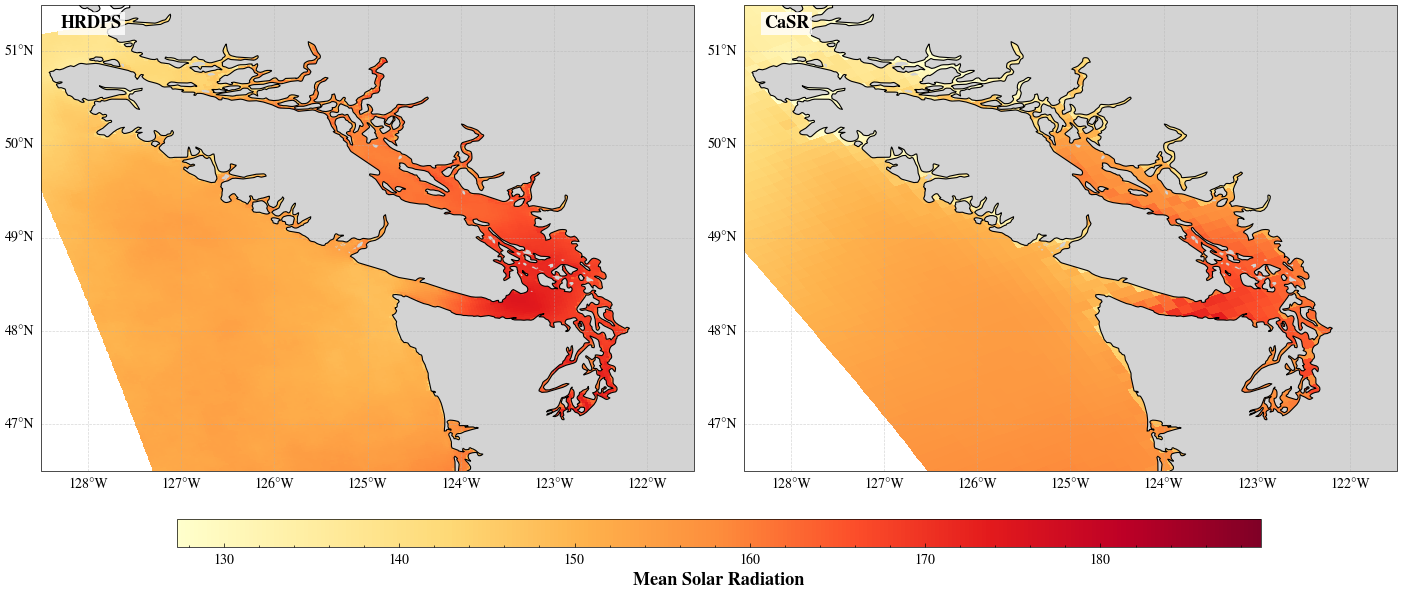

In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import scienceplots

# 启用 SciencePlots 风格
plt.style.use(['science', 'no-latex'])

# =========================
# Load data
# =========================

ds_h = xr.open_dataset("hrdps_2018_solar_radiation.nc")
ds_c = xr.open_dataset("casr_2018_solar_radiation.nc")

# HRDPS
lon_h = ds_h.nav_lon.values
lat_h = ds_h.nav_lat.values
solar_h = ds_h.mean_solar_radiation.values

# CASR
lon_c = ds_c.lon.values
lat_c = ds_c.lat.values
solar_c = ds_c.mean_solar_radiation.values


# =========================
# Convert longitude if needed
# e.g. 233E -> -127W
# =========================

def fix_lon(lon):
    return np.where(lon > 180, lon - 360, lon)

lon_h = fix_lon(lon_h)
lon_c = fix_lon(lon_c)


# =========================
# Auto map extent from both datasets
# =========================

lon_all = np.concatenate([lon_h.ravel(), lon_c.ravel()])
lat_all = np.concatenate([lat_h.ravel(), lat_c.ravel()])

lon_min = -128
lon_max = -122
lat_min = 47
lat_max = 51

# Add small padding
lon_pad = 0.5
lat_pad = 0.5

extent = [
    lon_min - lon_pad,
    lon_max + lon_pad,
    lat_min - lat_pad,
    lat_max + lat_pad
]


# =========================
# Shared color scale
# =========================

solar_all = np.concatenate([solar_h.ravel(), solar_c.ravel()])
vmin = np.nanpercentile(solar_all, 1)
vmax = np.nanpercentile(solar_all, 99)


# =========================
# Visualization: 1 x 2
# =========================

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 6),
    subplot_kw={"projection": proj},
    layout="constrained"
)


def setup_map(ax):
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)

    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False


# =========================
# HRDPS
# =========================

ax1 = axes[0]
setup_map(ax1)

pcm1 = ax1.pcolormesh(
    lon_h,
    lat_h,
    solar_h,
    transform=proj,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
    zorder=1
)

ax1.text(
    0.03,
    0.95,
    "HRDPS",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    zorder=10
)


# =========================
# CASR
# =========================

ax2 = axes[1]
setup_map(ax2)

pcm2 = ax2.pcolormesh(
    lon_c,
    lat_c,
    solar_c,
    transform=proj,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
    zorder=1
)

ax2.text(
    0.03,
    0.95,
    "CaSR",
    transform=ax2.transAxes,
    fontsize=13,
    fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    zorder=10
)


# =========================
# Shared colorbar
# =========================

cb = fig.colorbar(
    pcm1,
    ax=axes,
    orientation="horizontal",
    aspect=40,
    shrink=0.8,
    pad=0.05
)

cb.set_label("Mean Solar Radiation", fontsize=13, fontweight="bold")

plt.show()

## Visualization (scatter plot)



### Constructing data


In [ ]:
# Model data within the Salish Sea

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Matching lon lim
def normalize_lon(lon):
    return (lon + 180) % 360 - 180

# paths
path_casr = 'casr_2018_solar_radiation.nc'
path_hrdps = 'hrdps_2018_solar_radiation.nc'
path_bathy = '/data/nsoontie/MEOPAR/NEMO-forcing/grid/bathy_meter_SalishSea2.nc'

# load datasets
ds_casr = xr.open_dataset(path_casr)
ds_hrdps = xr.open_dataset(path_hrdps)
ds_bathy = xr.open_dataset(path_bathy)

# valid coordinates bathy>0
bathy_vals = ds_bathy['Bathymetry'].values[::8, ::8]
mask_water = bathy_vals > 0

nav_lon_sub = ds_bathy['nav_lon'].values[::8, ::8]
nav_lat_sub = ds_bathy['nav_lat'].values[::8, ::8]

water_lon = normalize_lon(nav_lon_sub[mask_water])
water_lat = nav_lat_sub[mask_water]

target_coords = np.column_stack((water_lon, water_lat))


def get_model_matched_data(ds, lon_var, lat_var, target_coords, var_names):
    """
    ds: xarray Dataset
    lon_var: longitude 变量名
    lat_var: latitude 变量名
    target_coords: 目标坐标数组
    var_names: 需要提取的变量名列表，如 ['mean_velocity', 'mean_velocity_squared']
    """
    model_lon = normalize_lon(ds[lon_var].values.flatten())
    model_lat = ds[lat_var].values.flatten()
    
    # get rid of nan in coordinates
    valid_coord_mask = ~(np.isnan(model_lon) | np.isnan(model_lat))
    model_lon = model_lon[valid_coord_mask]
    model_lat = model_lat[valid_coord_mask]
    
    # Build tree and query only ONCE
    tree = cKDTree(np.column_stack((model_lon, model_lat)))
    distances, indices = tree.query(target_coords)
    
    # extract all requested variables
    matched_results = []
    for var in var_names:
        model_var = ds[var].values.flatten()
        # 应用相同的空间 mask
        model_var = model_var[valid_coord_mask]
        # 根据 KDTree 的结果提取数据
        matched_results.append(model_var[indices])
        
    # 如果只请求了一个变量，直接返回该变量；如果请求了多个，返回元组便于解包
    if len(matched_results) == 1:
        return matched_results[0]
    else:
        return tuple(matched_results)



# coordinate matching

# 提取 HRDPS 的三个变量
hrdps_solar_radiation_mean = get_model_matched_data(
    ds_hrdps, 'nav_lon', 'nav_lat', target_coords, 
    ['mean_solar_radiation']
)

# 提取 CASR 的平均值
casr_solar_radiation_mean = get_model_matched_data(
    ds_casr, 'lon', 'lat', target_coords, 
    ['mean_solar_radiation']
)



### Scatter Plot



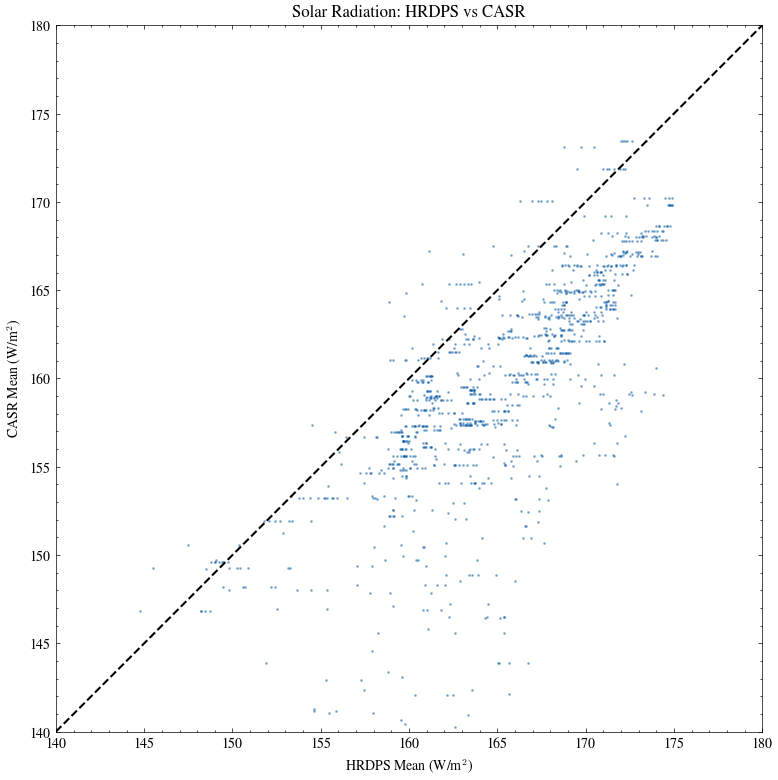

In [23]:
# Scatter Plot for Absolute Wind Speed Mean

import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# 启用 SciencePlots 风格
plt.style.use(['science', 'no-latex'])

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

scatter_kwargs = {
    's': 1,
    'alpha': 0.4,
    'color': 'C0'
}

diag_kwargs = {
    'color': 'k',
    'linestyle': '--',
    'linewidth': 1.5
}

def add_diagonal_line(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()])
    ]
    ax.plot(lims, lims, **diag_kwargs)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')


# 风速范围，可根据你的数据调整
v_lims = [140, 180]

# 如果有 NaN / inf，先过滤掉
mask = (
    np.isfinite(hrdps_solar_radiation_mean) &
    np.isfinite(casr_solar_radiation_mean)
)

x = hrdps_solar_radiation_mean[mask]
y = casr_solar_radiation_mean[mask]

# HRDPS vs CASR
ax.scatter(x, y, **scatter_kwargs)

ax.set_xlim(v_lims)
ax.set_ylim(v_lims)
add_diagonal_line(ax)

ax.set_title('Solar Radiation: HRDPS vs CASR')
ax.set_xlabel('HRDPS Mean (W/m$^2$)')
ax.set_ylabel('CASR Mean (W/m$^2$)')

plt.tight_layout()
plt.show()

## Time Series Comparison

This section plots the daily averaged solar radiation at the station of `Sandheads (49.11, -123.3)`.

In [ ]:
# Time Series at Sandheads
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================= 配置参数 =================
target_lat = 49.11
target_lon = -123.3
# 将单一年份改为一个年份列表，按需添加
years = [2020, 2021, 2022, 2023, 2024] 

# CaSR 文件路径 (包含所有年份)
casr_solar_file = '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_FB_SFC_2008_2024.nc'
casr_u_file = '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc'
casr_v_file = '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc'

# ================= 辅助函数 =================
def find_closest_index(lat_array, lon_array, target_lat, target_lon):
    """
    寻找二维经纬度网格中距离目标点最近的索引(i, j)
    """
    dist = (lat_array - target_lat)**2 + (lon_array - target_lon)**2
    return np.unravel_index(dist.argmin(), dist.shape)

def hrdps_preprocess(ds):
    # 只提取我们需要的变量，减少内存消耗
    vars_to_keep = ['u_wind', 'v_wind', 'solar', 'nav_lat', 'nav_lon']
    return ds[[v for v in vars_to_keep if v in ds.data_vars or v in ds.coords]]


# ================= 0. 预加载 CaSR 数据与网格信息 =================
print("正在加载 CaSR 总文件并定位目标网格...")
ds_casr_solar_full = xr.open_dataset(casr_solar_file)
ds_casr_u_full = xr.open_dataset(casr_u_file)
ds_casr_v_full = xr.open_dataset(casr_v_file)

# 确定 CaSR 的经纬度并计算最近点（在循环外只算一次，提高效率）
if 'lat' in ds_casr_solar_full and 'lon' in ds_casr_solar_full:
    casr_lat = ds_casr_solar_full['lat'].values
    casr_lon = ds_casr_solar_full['lon'].values
else:
    casr_lat = ds_casr_solar_full.coords.get('lat', ds_casr_solar_full.coords.get('rlat')).values
    casr_lon = ds_casr_solar_full.coords.get('lon', ds_casr_solar_full.coords.get('rlon')).values

is_casr_2d = casr_lat.ndim == 2
if is_casr_2d:
    idx_y_casr, idx_x_casr = find_closest_index(casr_lat, casr_lon, target_lat, target_lon)


# ================= 开启年份循环 =================
for year in years:
    year_str = str(year)
    print(f"\n================= 开始处理 {year_str} 年数据 =================")

    # ---------------- 1. 提取当年的 CaSR 数据 ----------------
    print(f"[{year_str}] 提取并计算 CaSR 数据...")
    # 从总数据集中截取当年数据
    ds_casr_solar = ds_casr_solar_full.sel(time=year_str)
    ds_casr_u = ds_casr_u_full.sel(time=year_str)
    ds_casr_v = ds_casr_v_full.sel(time=year_str)

    if is_casr_2d:
        solar_casr = ds_casr_solar['CaSR_v3.2_P_FB_SFC'][:, idx_y_casr, idx_x_casr]
        u_casr = ds_casr_u['CaSR_v3.2_P_UUC_10m'][:, idx_y_casr, idx_x_casr]
        v_casr = ds_casr_v['CaSR_v3.2_P_VVC_10m'][:, idx_y_casr, idx_x_casr]
    else:
        solar_casr = ds_casr_solar['CaSR_v3.2_P_FB_SFC'].sel(rlat=target_lat, rlon=target_lon, method='nearest')
        u_casr = ds_casr_u['CaSR_v3.2_P_UUC_10m'].sel(rlat=target_lat, rlon=target_lon, method='nearest')
        v_casr = ds_casr_v['CaSR_v3.2_P_VVC_10m'].sel(rlat=target_lat, rlon=target_lon, method='nearest')

    wind_speed_casr = np.sqrt(u_casr**2 + v_casr**2)

    df_casr = pd.DataFrame({
        'time': ds_casr_solar['time'].values,
        'CaSR_Solar': solar_casr.values,
        'CaSR_WindSpeed': wind_speed_casr.values
    }).set_index('time').resample('D').mean()


    # ---------------- 2. 提取当年的 HRDPS 数据 ----------------
    print(f"[{year_str}] 提取并计算 HRDPS 数据...")
    # 动态生成当前年份的文件路径
    hrdps_files = f'/results/forcing/atmospheric/GEM2.5/operational/ops_y{year_str}*.nc'
    
    ds_hrdps = xr.open_mfdataset(
        hrdps_files, 
        preprocess=hrdps_preprocess,
        combine='nested', 
        concat_dim='time_counter',
        parallel=True,
        chunks={'time_counter': 24}
    )

    # 每年重新寻找一次 HRDPS 索引（防止跨年出现网格微调，安全起见放在循环内）
    hrdps_lat = ds_hrdps['nav_lat'].values[0] if ds_hrdps['nav_lat'].ndim == 3 else ds_hrdps['nav_lat'].values
    hrdps_lon = ds_hrdps['nav_lon'].values[0] if ds_hrdps['nav_lon'].ndim == 3 else ds_hrdps['nav_lon'].values
    idx_y_hrdps, idx_x_hrdps = find_closest_index(hrdps_lat, hrdps_lon, target_lat, target_lon)

    solar_hrdps = ds_hrdps['solar'][:, idx_y_hrdps, idx_x_hrdps].compute()
    u_hrdps = ds_hrdps['u_wind'][:, idx_y_hrdps, idx_x_hrdps].compute()
    v_hrdps = ds_hrdps['v_wind'][:, idx_y_hrdps, idx_x_hrdps].compute()

    wind_speed_hrdps = np.sqrt(u_hrdps**2 + v_hrdps**2)

    df_hrdps = pd.DataFrame({
        'time': ds_hrdps['time_counter'].values,
        'HRDPS_Solar': solar_hrdps.values,
        'HRDPS_WindSpeed': wind_speed_hrdps.values
    }).set_index('time').resample('D').mean()


    # ---------------- 3. 数据合并与存储 ----------------
    df_combined = pd.concat([df_casr, df_hrdps], axis=1).dropna()
    out_filename = f'Sandheads_{year_str}_Daily_CaSR_vs_HRDPS.csv'
    df_combined.to_csv(out_filename)
    print(f"[{year_str}] 数据已成功保存至 {out_filename}")
    
    # 释放当前年份 HRDPS 数据占用的内存
    ds_hrdps.close()

# 关闭 CaSR 的总文件句柄
ds_casr_solar_full.close()
ds_casr_u_full.close()
ds_casr_v_full.close()

print("\n所有年份处理完毕！")

### Daily Comparison

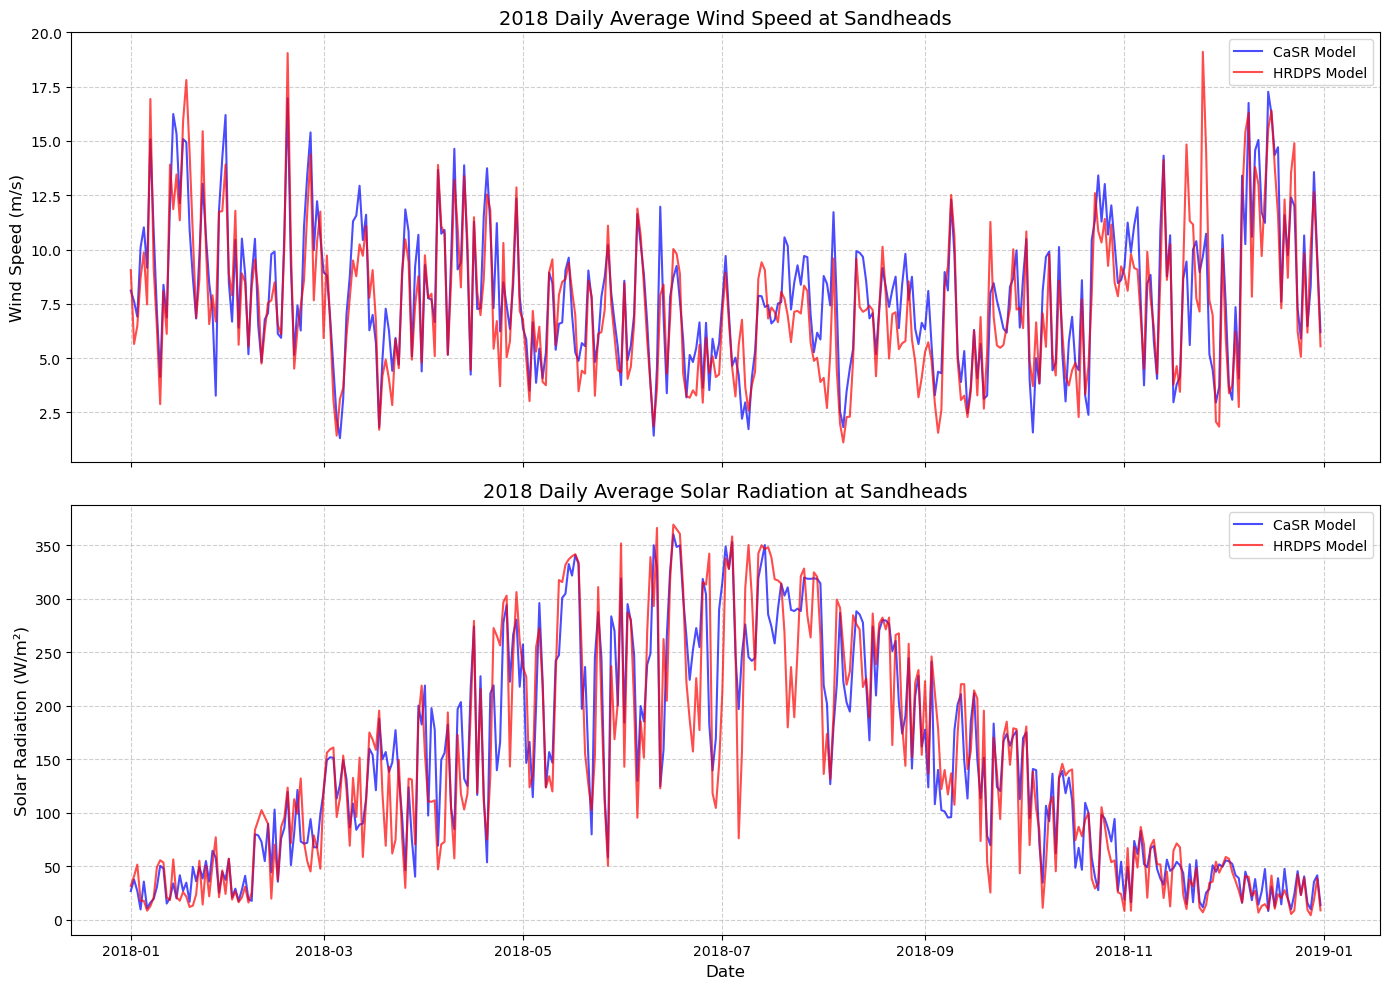

In [4]:

# 时序对比图 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 绘制日均风速对比
ax1.plot(df_combined.index, 0.51*df_combined['CaSR_WindSpeed'], label='CaSR Model', color='blue', alpha=0.7)
ax1.plot(df_combined.index, df_combined['HRDPS_WindSpeed'], label='HRDPS Model', color='red', alpha=0.7)
ax1.set_title('2018 Daily Average Wind Speed at Sandheads', fontsize=14)
ax1.set_ylabel('Wind Speed (m/s)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# 绘制日均太阳辐射对比
ax2.plot(df_combined.index, df_combined['CaSR_Solar'], label='CaSR Model', color='blue', alpha=0.7)
ax2.plot(df_combined.index, df_combined['HRDPS_Solar'], label='HRDPS Model', color='red', alpha=0.7)
ax2.set_title('2018 Daily Average Solar Radiation at Sandheads', fontsize=14)
ax2.set_ylabel('Solar Radiation (W/m²)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Monthly Comparison

In [3]:
import pandas as pd

path_data='/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_comparison/Sandheads_2018_Daily_CaSR_vs_HRDPS.csv'

da=pd.read_csv(path_data)

da.head()

,time,CaSR_Solar,CaSR_WindSpeed,HRDPS_Solar,HRDPS_WindSpeed
0,2018-01-01,26.742188,15.905290,31.537237,9.061893
1,2018-01-02,37.431640,14.949963,40.454360,5.653595
2,2018-01-03,26.813150,13.549599,51.497875,6.483505
3,2018-01-04,9.550781,19.786476,17.589226,8.704617
4,2018-01-05,35.578777,21.609694,17.681767,9.869022


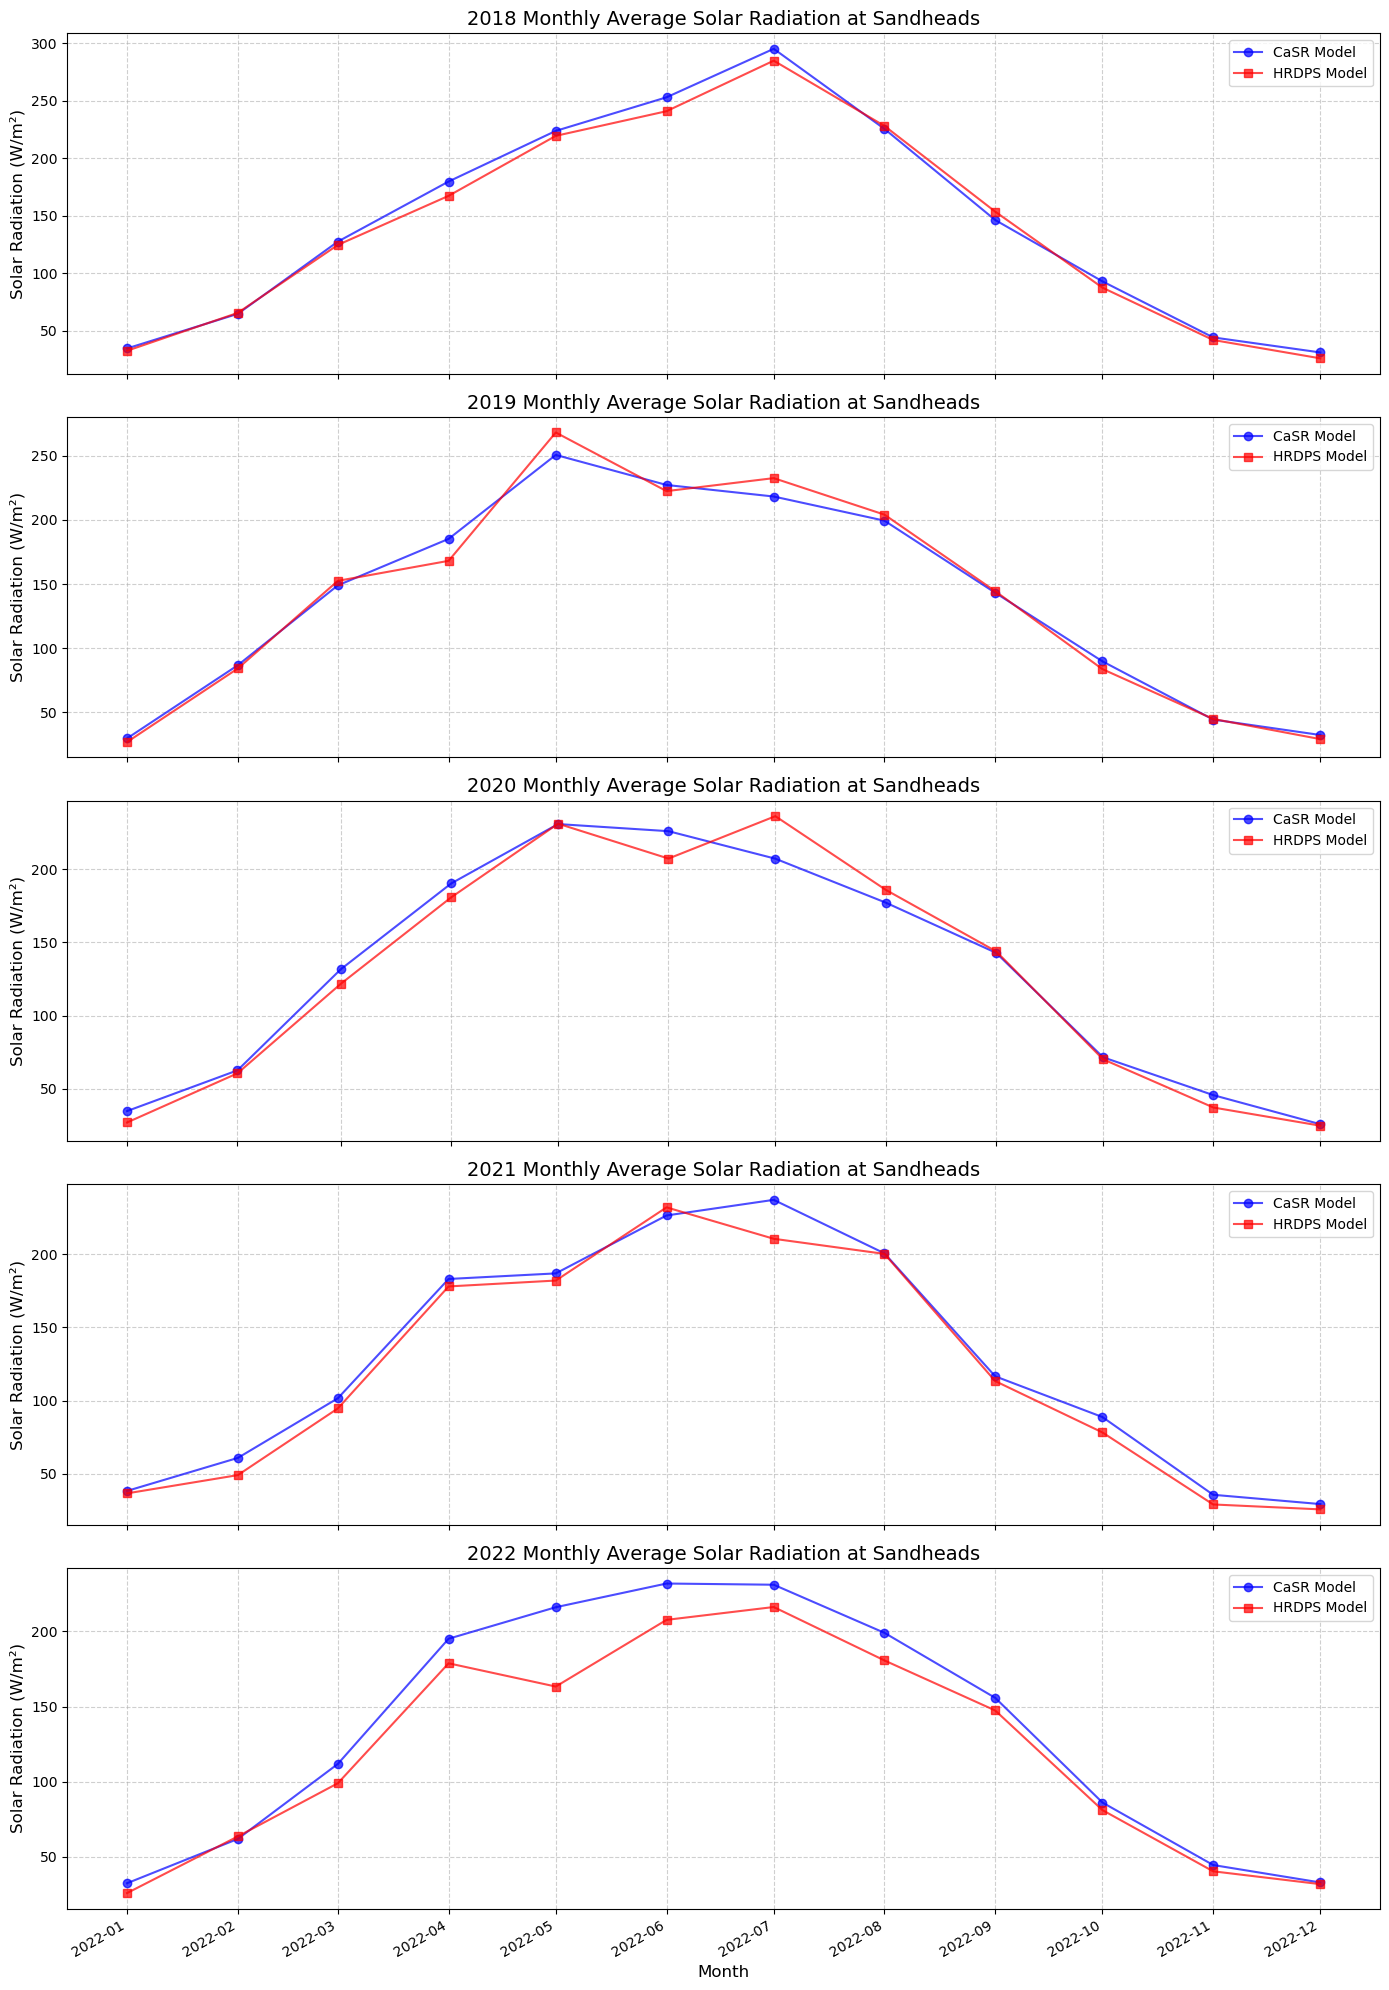

In [4]:
# Monthly visualization: 2018-2023
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 定义需要遍历的年份
years = range(2018, 2023)
num_years = len(years)

# 创建多行1列的子图，根据年份数量动态调整图片高度 (每张图高度设为4)
fig, axes = plt.subplots(nrows=num_years, ncols=1, figsize=(14, 4 * num_years))

# 文件路径模板，使用 {year} 占位符
path_template = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_comparison/Sandheads_{year}_Daily_CaSR_vs_HRDPS.csv'

# 遍历每一年并绘图
for i, year in enumerate(years):
    ax = axes[i] # 获取当前年份对应的子图对象
    path_data = path_template.format(year=year)
    
    try:
        # 读取数据
        da = pd.read_csv(path_data)
    except FileNotFoundError:
        print(f"警告：未找到 {year} 年的数据文件，跳过该年。路径: {path_data}")
        continue

    # 数据预处理：转换时间格式并计算月均值
    da['time'] = pd.to_datetime(da['time'])
    da.set_index('time', inplace=True)
    da_monthly = da.resample('MS').mean()

    # 绘制月平均太阳辐射对比图
    ax.plot(da_monthly.index, da_monthly['CaSR_Solar'], marker='o', label='CaSR Model', color='blue', alpha=0.7)
    ax.plot(da_monthly.index, da_monthly['HRDPS_Solar'], marker='s', label='HRDPS Model', color='red', alpha=0.7)

    # 设置标题和标签
    ax.set_title(f'{year} Monthly Average Solar Radiation at Sandheads', fontsize=14)
    ax.set_ylabel('Solar Radiation (W/m²)', fontsize=12)
    
    # 为了美观，只在最底部的子图添加 X 轴的总标签
    if i == num_years - 1:
        ax.set_xlabel('Month', fontsize=12)

    # 设置图例和网格
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

    # 优化 X 轴显示格式，使其按月显示（如 2018-01）
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

# 自动旋转所有子图的日期标签以防重叠
fig.autofmt_xdate() 

# 调整布局以防止子图之间的标题和坐标轴重叠
plt.tight_layout()
plt.show()

In [ ]:
# Monthly visualization: 2018-2022 Heatmap Comparison
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 定义需要遍历的年份
years = range(2018, 2023)

# 文件路径模板，使用 {year} 占位符
path_template = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_model_comparison/Sandheads_{year}_Daily_CaSR_vs_HRDPS.csv'

# 创建一个空的列表来收集所有年份的数据
all_years_data = []

# 遍历每一年并处理数据
for year in years:
    path_data = path_template.format(year=year)
    
    try:
        # 读取数据
        da = pd.read_csv(path_data)
    except FileNotFoundError:
        print(f"警告：未找到 {year} 年的数据文件，跳过该年。路径: {path_data}")
        continue

    # 数据预处理：转换时间格式并计算月均值
    da['time'] = pd.to_datetime(da['time'])
    da.set_index('time', inplace=True)
    da_monthly = da.resample('MS').mean()
    
    # 计算差值：CaSR - HRDPS
    # 正值代表 CaSR 大，负值代表 HRDPS 大
    da_monthly['Difference'] = da_monthly['CaSR_Solar'] - da_monthly['HRDPS_Solar']
    da_monthly['Year'] = year
    da_monthly['Month'] = da_monthly.index.month
    
    # 只保留我们需要画图的列
    all_years_data.append(da_monthly[['Year', 'Month', 'Difference']])

# 将所有年份的数据合并成一个 DataFrame
df_combined = pd.concat(all_years_data)

# 将数据透视为二维表格，行是年份，列是月份
pivot_df = df_combined.pivot(index='Year', columns='Month', values='Difference')

# ================= 绘图部分 =================
plt.figure(figsize=(12, 6))

# 绘制热力图
# cmap='RdBu_r': 使用红蓝配色（红色代表正数/CaSR大，蓝色代表负数/HRDPS大）
# center=0: 确保 0 对应颜色中间的白色
# annot=True: 在格子里显示具体的差值数字（如果不想要数字，改为 False）
# fmt=".1f": 数字保留一位小数
ax = sns.heatmap(pivot_df, cmap='RdBu_r', center=0, annot=True, fmt=".1f", 
                 linewidths=.5, cbar_kws={'label': 'Difference: CaSR - HRDPS (W/m²)'})

# 设置标题和标签
% plt.title('Monthly Model Comparison: CaSR vs HRDPS (2018-2022)', fontsize=15, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)

# 调整 Y 轴标签的角度，使其水平显示，方便阅读
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'